## 04 - Customer Segmentation

### Objetivo
Diseñar y ejecutar una segmentación de clientes que permita distinguir:
- clientes fieles,
- compradores esporádicos,
- clientes en riesgo de abandono.

### Enfoque
Se utilizará una segmentación conductual basada en RFM:
- Recency: qué tan reciente fue la última compra
- Frequency: cuántas veces compró
- Monetary: cuánto gastó

### Justificación
Para el área de marketing, RFM ofrece segmentos interpretables, accionables y fáciles de traducir a campañas.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.loaders import load_all_datasets
from src.features.customer_features import (
    build_order_level_base,
    build_customer_rfm,
    add_rfm_scores,
    assign_customer_segment,
)

In [2]:
bundle = load_all_datasets()

customers = bundle.customers.copy()
orders = bundle.orders.copy()
order_items = bundle.order_items.copy()

In [3]:
order_base = build_order_level_base(
    orders=orders,
    order_items=order_items,
    customers=customers,
)

customer_rfm = build_customer_rfm(order_base)
customer_rfm = add_rfm_scores(customer_rfm)
customer_rfm = assign_customer_segment(customer_rfm)

customer_rfm.head()

,customer_unique_id,last_purchase_date,frequency,monetary,avg_order_value,total_items,n_cities,main_state,main_city,recency_days,R_score,F_score,M_score,RFM_score,rfm_numeric_score,customer_segment
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,129.90,129.90,1,1,SP,cajamar,112,4,1,4,414,9,Recent occasional
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,18.90,18.90,1,1,SP,osasco,115,4,1,1,411,6,Recent occasional
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,69.00,69.00,1,1,SC,sao jose,537,1,1,2,112,4,At risk / churn
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,25.99,25.99,1,1,PA,belem,321,2,1,1,211,4,At risk / churn
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,180.00,180.00,1,1,SP,sorocaba,288,2,1,5,215,8,At risk / churn


In [4]:
segment_summary = (
    customer_rfm.groupby("customer_segment", as_index=False)
    .agg(
        n_customers=("customer_unique_id", "nunique"),
        avg_recency_days=("recency_days", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        avg_order_value=("avg_order_value", "mean"),
    )
    .sort_values("n_customers", ascending=False)
    .reset_index(drop=True)
)

segment_summary["share_pct"] = segment_summary["n_customers"] / segment_summary["n_customers"].sum()
segment_summary

,customer_segment,n_customers,avg_recency_days,avg_frequency,avg_monetary,avg_order_value,share_pct
0,Occasional,29520,235.551863,1.009790,62.735650,62.498617,0.316202
1,At risk / churn,14986,395.508141,1.000000,140.884861,140.884861,0.160522
2,Recent occasional,14984,90.878404,1.000000,139.310412,139.310412,0.160500
3,At risk high-value,13192,393.484688,1.071180,214.608009,205.271939,0.141306
4,Loyal,7278,91.279198,1.022671,164.423045,163.422945,0.077958
5,Frequent valuable,6881,220.931696,1.088941,197.233847,185.422367,0.073706
6,Loyal high-value,6517,91.462176,1.171091,274.032242,248.669396,0.069807


In [ ]:
## Lectura ejecutiva
- Loyal high-value: clientes más valiosos y fieles
- Loyal: clientes recurrentes con buen potencial de retención
- Recent occasional: clientes recientes, todavía no fidelizados
- At risk high-value: clientes que antes eran valiosos y hoy muestran enfriamiento
- At risk / churn: clientes con baja recurrencia y alta recencia
- Occasional: clientes esporádicos

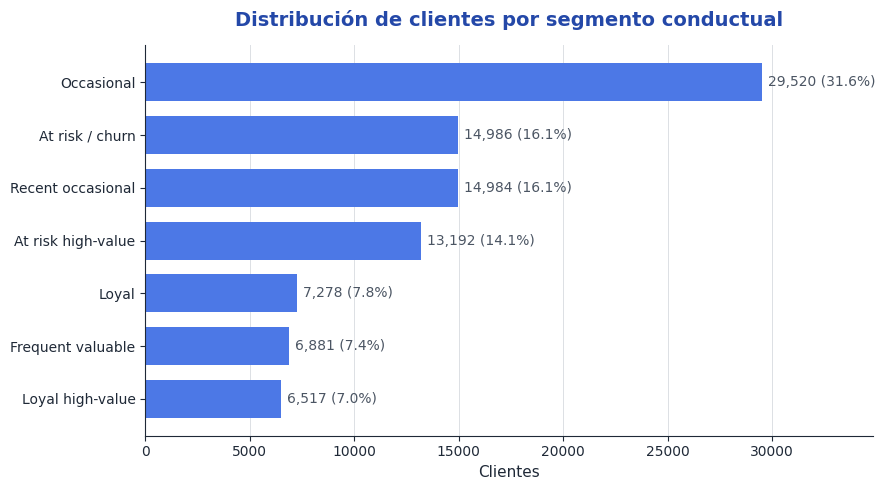

In [5]:
TP_COLORS = {
    "blue_primary": "#2448A8",
    "blue_secondary": "#4C78E6",
    "blue_soft": "#6EC1E4",
    "yellow_accent": "#F2D22E",
    "gray_bg": "#F3F4F6",
    "gray_text": "#4B5563",
    "gray_muted": "#D1D5DB",
    "gray_dark": "#1F2937",
    "white": "#FFFFFF",
}

def fmt_pct(x, pos=None):
    return f"{x:.0%}"

plot_df = segment_summary.sort_values("n_customers", ascending=True).copy()

fig, ax = plt.subplots(figsize=(9, 5), facecolor=TP_COLORS["white"])
ax.set_facecolor(TP_COLORS["white"])

ax.barh(
    plot_df["customer_segment"],
    plot_df["n_customers"],
    color=TP_COLORS["blue_secondary"],
    edgecolor="none",
    height=0.72
)

ax.set_title(
    "Distribución de clientes por segmento conductual",
    fontsize=14,
    fontweight="bold",
    color=TP_COLORS["blue_primary"],
    pad=14
)
ax.set_xlabel("Clientes", color=TP_COLORS["gray_dark"], fontsize=11)
ax.set_ylabel("")

for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
ax.spines["left"].set_color(TP_COLORS["gray_dark"])
ax.spines["bottom"].set_color(TP_COLORS["gray_dark"])

ax.tick_params(axis="x", colors=TP_COLORS["gray_dark"], labelsize=10)
ax.tick_params(axis="y", colors=TP_COLORS["gray_dark"], labelsize=10)

ax.xaxis.grid(True, linestyle="-", linewidth=0.7, color=TP_COLORS["gray_muted"], alpha=0.75)
ax.set_axisbelow(True)

max_val = plot_df["n_customers"].max()

for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(
        row["n_customers"] + max_val * 0.01,
        i,
        f'{row["n_customers"]:,.0f} ({row["share_pct"]:.1%})',
        va="center",
        ha="left",
        color=TP_COLORS["gray_text"],
        fontsize=10
    )

ax.set_xlim(0, max_val * 1.18)

plt.tight_layout()
plt.show()

In [7]:
segment_export = customer_rfm[[
    "customer_unique_id",
    "customer_segment",
    "recency_days",
    "frequency",
    "monetary",
    "avg_order_value",
    "main_state",
    "main_city",
]]

segment_export.head()

,customer_unique_id,customer_segment,recency_days,frequency,monetary,avg_order_value,main_state,main_city
0,0000366f3b9a7992bf8c76cfdf3221e2,Recent occasional,112,1,129.90,129.90,SP,cajamar
1,0000b849f77a49e4a4ce2b2a4ca5be3f,Recent occasional,115,1,18.90,18.90,SP,osasco
2,0000f46a3911fa3c0805444483337064,At risk / churn,537,1,69.00,69.00,SC,sao jose
3,0000f6ccb0745a6a4b88665a16c9f078,At risk / churn,321,1,25.99,25.99,PA,belem
4,0004aac84e0df4da2b147fca70cf8255,At risk / churn,288,1,180.00,180.00,SP,sorocaba
